## TO do
POSITIONAL ENCODING

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                  
    transforms.Normalize((0.5,), (0.5,)),     
])

train_set = datasets.MNIST(
    root="./data",        
    train=True,
    download=True,
    transform=transform,
)

test_set = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.16MB/s]


In [3]:
train_set[0][0].shape

torch.Size([1, 28, 28])

In [4]:
class PatchEmbedding(nn.Module):
    """
    A layer that splits an image into patches and projects each patch to an embedding vector.
    Used as the input layer of a Vision Transformer (ViT).

    Inputs:
    - img_size: Integer representing the height/width of input image (assumes square image).
    - patch_size: Integer representing height/width of each patch (square patch).
    - in_channels: Number of input image channels
    - embed_dim: Dimension of the linear embedding space.
    """
    def __init__(self, img_size, patch_size, in_channels=1, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        assert img_size%patch_size==0, "img dim must be divisible by patch_size"
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size
        self.proj = nn.Linear(self.patch_dim, embed_dim)
        self.embed_dim = embed_dim

    def forward(self, x):
        """
        input: x.shape = (B, C, H, W); C == in_channels
        
        patch_dim = C* patch_size * patch_size
        num_patches = (H//p) * (W//p)

        output: patchified img: (B, num_patches, embed_dim)
        """
        B, C, _, _ = x.shape
        p = self.patch_size
        x = x.view(B, C,  self.img_size//p, self.img_size//p, p, p)
        # print(x.is_contiguous())
        x = x.permute(0,3,1,2,4,5)
        # print(x.is_contiguous())

        x = x.reshape(B, self.num_patches, self.patch_dim)
        # print(x.is_contiguous())
        return self.proj(x)

class DepatchLinear(nn.Module):
    """
    A layer that "depatchify" the output of our ViT, and projects it + reshape
    Used as the output layer of a Vision Transformer (ViT).

    Inputs:
    - img_size: Integer representing the height/width of input image (assumes square image).
    - patch_size: Integer representing height/width of each patch (square patch).
    - in_channels: Number of input image channels
    - embed_dim: Dimension of the linear embedding space.
    """
    def __init__(self, img_size, patch_size, in_channels=1, embed_dim=64):
        super().__init__()
        self.in_channels = in_channels
        self.img_size = img_size
        self.patch_size = patch_size
        self.patch_dim = in_channels * patch_size * patch_size
        self.proj = nn.Linear(embed_dim , self.patch_dim)
        self.size = img_size//patch_size
    def forward(self, x):
        """        
        output mean and variance to put in the decoder?
        patch_dim = C* patch_size * patch_size
        num_patches = (H//p) * (W//p)

        input: patchified: (B, num_patches, embed_dim)
        output: mu/sigma.shape = (B, C, H, W); C == in_channels
        """
        B, _, _ = x.shape
        X = self.proj(x)
        X = X.reshape(B, self.size, self.size, self.in_channels, self.patch_size, self.patch_size)
        
        X = X.permute(0, 3, 1, 2, 4, 5)
        # we now have to use reshape, otherwise we have some contiguos problem, pytorch could deal with taht in patch but not here 
        # with 2 view
        X = X.reshape(B, self.in_channels, self.img_size, self.img_size)
        return X

Check en profonduer pourquoi faut reshape et view marche pas alors que ça marchait sur patchembedding

In [5]:
## test
x = torch.randn(5, 1, 28, 28)
patching_test = PatchEmbedding(28, 7, 1, 64)
depatching_test = DepatchLinear(28, 7, 1, 64)
out = patching_test(x)
print(f'out Patch_embedding: {out.shape}')
out = depatching_test(out)
print(f'out depatch_embedding: {out.shape}, inital shape: {x.shape}')


out Patch_embedding: torch.Size([5, 16, 64])
out depatch_embedding: torch.Size([5, 1, 28, 28]), inital shape: torch.Size([5, 1, 28, 28])


In [6]:
import math
def embedsinus(dim, x):
    """
    x -> (B,)
    """
    N=10000 #Attention is all you need  N**(k/(dim//2)) 
    h_dim = dim//2
    emb = math.log(N)/(h_dim)
    emb = torch.exp(torch.arange(h_dim, device= x.device) * -emb) # (h_dim,)  
    emb = x[:, None] * emb[None,:] #careful with broadcast
    return torch.cat((emb.sin(), emb.cos()), dim=-1)

    
def pearson(a, b, dim=-1, eps=1e-8):
    a = a - a.mean(dim=dim, keepdim=True)
    b = b - b.mean(dim=dim, keepdim=True)
    return F.cosine_similarity(a, b, dim=dim, eps=eps)




def pe2d(num_patch, emb_dim):
    grid_size = int(num_patch**0.5)
    rows = torch.arange(grid_size)
    cols = torch.arange(grid_size)
    assert grid_size**2==num_patch, "num_patch has to be a square"
    assert emb_dim%4==0, "emb_dim has to be divisible by 4"
    rows = embedsinus(emb_dim // 2, rows)
    cols = embedsinus(emb_dim // 2, cols) 
    # what we do here is a bit more trickier than 1D 
    # we do a grid of positional encoding (col(i), row(j)) for the matrix/grid
    #we then flatten to get (1, num_patch, emb_dim)
    pe_r = rows[:, None, :].expand(grid_size, grid_size, emb_dim // 2)
    pe_c = cols[None, :, :].expand(grid_size, grid_size, emb_dim // 2)
    pe = torch.cat([pe_r, pe_c], dim=-1)
    return pe.view(1, num_patch, emb_dim)
embedsinus(16, torch.randn(5)).shape
# pe2d(9,16)

class PositionalEmbedding(nn.Module):
    def __init__(self,num_patch, emb_dim):
        super().__init__()
        pe = pe2d(num_patch, emb_dim)
        self.register_buffer("pe", pe)

    def forward(self, x):
        
        # if epch%10==0:
        #     val = pearson(self.pe, x, dim=-1).abs().mean().item()
        #     list_cosine.append(val)
        return x + self.pe

## Positional embedding

Pos embedding is trickier than it might seem. To understand why this works and how we do that, remember that we want to encode positional embedding which we can choose to be constant. We need something to describe positions and apparently 2 things seem important: the distance relation between 2 positions and the position itself, you can think of it as looking for a wide stationnary process?   
X(t) = (cos(ft), sin(ft)) where f is chosen.  
Now how exactly by just adding some values will the model "understands" the positional information. Key insight is what happens with attention where x' = x + pe, pe=pos encoding. Another insight is thinking of gradient flow: just a&dding some fixed input as pe will not influence gradient flow backward, but the forward values. Remember that (f(g(x)))' = f'(g(x))g'(x) with g(x) = x + pe, we still have g(x) appearing in the gradient values which then influents the model.
We destroy equivariance across values??


In [ ]:

class MultiHeadAtt(nn.Module):
    """
    MultiHeadAttention ??
    """
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.key = nn.Linear(embed_dim, embed_dim)
        self.query = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        
        self.attn_drop = nn.Dropout(dropout)
        assert embed_dim%num_heads==0, "emb_dim has to be divisible by num_heads"
        self.n_head = num_heads
        self.emb_dim = embed_dim
        self.head_dim = self.emb_dim // self.n_head

    def forward(self, query, key, value, attn_mask=None):
        """
        inputs: 
        query = (B, P, E)
        key = (B, T, E)
        value = (B, T, E') ? E=E' 
        P = patch_nums or sequence length 
        T = flexibile dim ? Target sequence
        E = emb_dim

        with T being target numbers of patch here for DiT? Target sequence length in NLP
        output: vect = (B, P, E) 
        Remember that we can choose depending on attention what do we put in query, key or value

        Self-attention: query=key=value=input
        Cross-attention: query=input, key=value=context

        """
        B, P, E = query.shape
        _, T, _ = key.shape

        queries = self.query(query).view(B, P, self.n_head, self.head_dim).transpose(1,2) # (B,P,E) -> (B, h, P, E//h)
        keys = self.key(key).view(B, T, self.n_head, self.head_dim).transpose(1,2) # (B, T, E) -> (B, h, T, E//h)
        values = self.value(value).view(B, T,self.n_head, self.head_dim).transpose(1,2) # (B, T, E') -> (B, h, T, E//h)

        # print(keys.shape, queries.shape)
        dot = queries @ keys.transpose(-2, -1)

        if attn_mask is not None:
          dot = dot.masked_fill_(attn_mask==0, float('-inf')) # in case I want to add some mask, but useless in DiT usually

        product = self.attn_drop(F.softmax(dot/np.sqrt(self.head_dim), -1)) # (B, h, P, T)
        out = product @ values # (B, h, P, T) @ (B, h, T, E//h) = (B, h, P, E//h)
        out = out.transpose(1,2).reshape(B, P, E) # here we need reshape or contiguous().view()
        return self.proj(out) 

# q = torch.randn(5, 16, 64)
# k = torch.randn(5, 8, 64)
# v =  torch.randn(5, 8, 64)
# att = MultiHeadAtt(64, 1)
# x = att(q, k, v)
# print(x.shape)

class MLP(nn.Module):
    """
    Designing a MLP 
    """
    def __init__(self, input_dim, dims):
        super().__init__()
        self.proj1 = nn.Linear(input_dim, dims[0])
        self.mods = nn.ModuleList([])
        dim_c = list(zip(dims[:-1], dims[1:]))
        for dim0, dim1 in dim_c :
            layer = nn.ModuleList([nn.SiLU(), nn.Linear(dim0, dim1) ])
            self.mods.append(layer)
    def forward(self, x):
        x = self.proj1(x)
        for layer in self.mods:
            act, fc = layer
            x = fc(act(x))
        return x
    

# con = MLP(5, [18, 26, 12])
# test_x_mlp = torch.randn(5,)
# print(con(test_x_mlp).shape)




    
class BlockadaLN(nn.Module):
    """
    DiT adaLN block of the DiT paper
    """
    def __init__(self,num_heads, emb_dim, cond_dim):
        super().__init__()
        self.selfatt = MultiHeadAtt(emb_dim, num_heads)
        self.mlp_cond = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, 6 * emb_dim))
        nn.init.zeros_(self.mlp_cond[-1].weight)
        nn.init.zeros_(self.mlp_cond[-1].bias)
        self.lnorm1 = nn.LayerNorm(emb_dim)
        # self.lnorm1 = nn.RMSNorm()
        self.lnorm2 = nn.LayerNorm(emb_dim)
        # self.lnorm2 = nn.RMSNorm()
        self.ffn = MLP(emb_dim, [4 * emb_dim, emb_dim])

    def forward(self, x, cond):
        """
        cond could be time only or both time and conditioning

        inputs = (B, P, E): x, (B, E'): cond

        output = (B, P, E)
        """
        sc1 = x
        x = self.lnorm1(x)
        cond = self.mlp_cond(cond)
        s1, s2, s3 = cond.chunk(3, dim=-1)
        s1, s2, s3 = s1[:, None, :], s2[:, None, :], s3[:, None, :]


        scale1, shift1 = s1.chunk(2, dim=-1)
        x = x * (1 + scale1) + shift1
        x = self.selfatt(query=x, key=x, value=x)

        scale2, scale4 = s2.chunk(2, dim=-1)
        x =  x * (scale2)
        x = x + sc1
        sc2 = x
        x = self.lnorm2(x)
        
        scale3, shift3 = s3.chunk(2, dim=-1)
        x = x * (1 + scale3) + shift3

        x = self.ffn(x) * (scale4)
        return x + sc2

# x = torch.randn(8, 16, 32)
# cond = torch.randn(8, 16)
# block_test = BlockadaLN(8, 32, 16)
# print(block_test(x, cond).shape)

In [14]:
import math
class Sinusembed(nn.Module):
    """
    sinusoidal embedding of time
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        """
        t -> (B,)
        output: (B, dim)
        """
        # device = x.device # maybe if I want to train on gpu with bigger models than mnist
        N=10000 #Attention is all you need  N**(k/(dim//2)) 
        h_dim = self.dim//2
        emb = math.log(N)/(h_dim)
        emb = torch.exp(torch.arange(h_dim, device=t.device) * -emb) # (h_dim,)  # I have to know when to put device or not (now I know)
        emb = t[:, None] * emb[None,:] #careful with broadcast
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


# TEST ORTHOGONALITY SOMME POS + X? ADALN? dans le train/ 

In [9]:
class DiT(nn.Module):
    """
    The whole DiT architecture
    """
    def __init__(self,num_patch, num_heads, cond_emb, emb_dim, img_size, num_cond_emb, in_channels=1):
        """
        num_patch/patch_size: I could put one of the two, but number of patch seemed better
        you can deduce patch_size from num_patch and img_size.


        num_heads = [1, 2, 3 ???]: determines numbers of DiT blocks and params
        we keep the same cond_dim and emb_dim across all DiT blocks
        emb_dim = dim of the embedding after patchify
        cond_emb: dim of the conditional embedding
        num_cond_emb: size of the dictionary of embeddings for the conditioning??
        """
        super().__init__()
        assert (int(num_patch**0.5)*int(num_patch**0.5))==num_patch, "num_patch has to be a square"
        assert (img_size%int(num_patch**0.5)==0), "num_patch**0.5 has to divide img_size"
        assert cond_emb%4==0, "cond_emb has to be divisible by 4"
        patch_size = int(img_size//(num_patch**0.5))

        self.patchemb = PatchEmbedding(img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=emb_dim)
        self.num_patch = num_patch
        self.pos_emb = PositionalEmbedding(self.num_patch, emb_dim)
        self.ditblocks = nn.ModuleList([BlockadaLN(num_head, emb_dim, cond_emb) for num_head in num_heads])
        self.time_emb = Sinusembed(cond_emb)
        self.emb_cond = nn.Embedding(num_cond_emb, cond_emb)
        self.lastnorm = nn.LayerNorm(emb_dim)
        self.depatchify = DepatchLinear(img_size, patch_size, in_channels, emb_dim)

    def forward(self, x, t, cond=None):
        """
        inputs: x=(B, C, H, W), t=(B,), cond=(?)

        output: speed X1 - X0 (we're doing rectified flow)
        """
        conditioning = self.time_emb(t)
        if cond is not None:
            embed_cond = self.emb_cond(cond)
            conditioning += embed_cond
        x = self.patchemb(x)
        x = self.pos_emb(x)
        for ditblock in self.ditblocks:
            x = ditblock(x, conditioning)
        x = self.lastnorm(x)
        v = self.depatchify(x)
        return v

Time is 1 now don't forget to scale by a factor

In [10]:
# ## test
# x = torch.randn(5,4,32,32)
# t = torch.randn(5,)
# dit = DiT(4,[2,2,2] ,16,32,32, 5, 4)
# v = dit(x, t)
# print(f'speed X1-X0:{v.shape}, input_shape={x.shape} ')

In [ ]:
class DiTModel():
    def __init__(self, model, time_scale):
        """
        we need time_scale, cause t in [0,1] make our embeddings useless since
        we didn't change the factor N.
        """
        self.model = model
        self.time_scale = time_scale

    def loss(self, x0, cond=None):
        """
        x0 = data (B, C, H, W)
        x1 = noise
        t must be of shape (B,) as input of the model
        """
        B = x0.shape[0]
        x1 = torch.randn_like(x0, device=x0.device) 
        # t must be of shape (B,) as input of the model
        t  = torch.rand(B, device=x0.device)
        xt = t[:, None, None, None] * x0 + (1-t[:, None, None, None]) * x1 # we want to go from data to noise 
        v = x1 - x0
        vt = self.model(xt, t * self.time_scale, cond=cond)
        return F.mse_loss(vt, v)
    @torch.no_grad()
    def sample(self, shape, n_steps=100, cond=None, device="cpu"):
        """
        shape = (B, C, H, W)
        
        """
        self.model.eval()
        x = torch.randn(shape, device=device)        # x1 ~ N(0,I), t=0
        dt = 1.0 / n_steps
        for i in range(n_steps):
            t = torch.full((shape[0],), i * dt, device=device)   # (B,)
            v = self.model(x, t * self.time_scale, cond=cond)    
            x = x - v * dt                                        # dx/dt = -v
        return x





In [12]:
# ## test
# x = torch.randn(5,4,32,32)
# t = torch.randn(5,)
# dit = DiT(4,[2,2,2] ,16,32,32, 5, 4)
# ditmod = DiTModel(dit, 1000)
# v = ditmod.loss(x)
# print(f'speed X1-X0:{v}, input_shape={x.shape} ')

## Trainloop

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# head_dim ) emb_dim/ num_heads
model = DiT(
    num_patch=196,
    num_heads=[4, 4, 4, 4],
    cond_emb=64,
    emb_dim=128,
    img_size=28,
    num_cond_emb=10,
    in_channels=1,
).to(device)

flow = DiTModel(model, time_scale=1000.0)
opt = optim.Adam(model.parameters(), lr=5e-4)

n_epochs = 30
model.train()

for epoch in range(n_epochs):
    running = 0.0
    for x0, _ in train_loader:
        x0 = x0.to(device)

        loss = flow.loss(x0, cond=None)
        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item()

    print(f"epoch {epoch:3d} | loss moyen {running / len(train_loader):.5f}")


epoch   0 | loss moyen 1.21245
epoch   1 | loss moyen 0.35130
epoch   2 | loss moyen 0.29541
epoch   3 | loss moyen 0.28262
epoch   4 | loss moyen 0.27061
epoch   5 | loss moyen 0.25504
epoch   6 | loss moyen 0.24501
epoch   7 | loss moyen 0.23681
epoch   8 | loss moyen 0.22954
epoch   9 | loss moyen 0.22369
epoch  10 | loss moyen 0.22002
epoch  11 | loss moyen 0.21671
epoch  12 | loss moyen 0.21408
epoch  13 | loss moyen 0.21129
epoch  14 | loss moyen 0.20940
epoch  15 | loss moyen 0.20807
epoch  16 | loss moyen 0.20510
epoch  17 | loss moyen 0.20380
epoch  18 | loss moyen 0.20239
epoch  19 | loss moyen 0.20029
epoch  20 | loss moyen 0.19990
epoch  21 | loss moyen 0.19917
epoch  22 | loss moyen 0.19736
epoch  23 | loss moyen 0.19671
epoch  24 | loss moyen 0.19620
epoch  25 | loss moyen 0.19585
epoch  26 | loss moyen 0.19395
epoch  27 | loss moyen 0.19362
epoch  28 | loss moyen 0.19380
epoch  29 | loss moyen 0.19246


In [ ]:
1/np.sqrt(64)

np.float64(0.125)

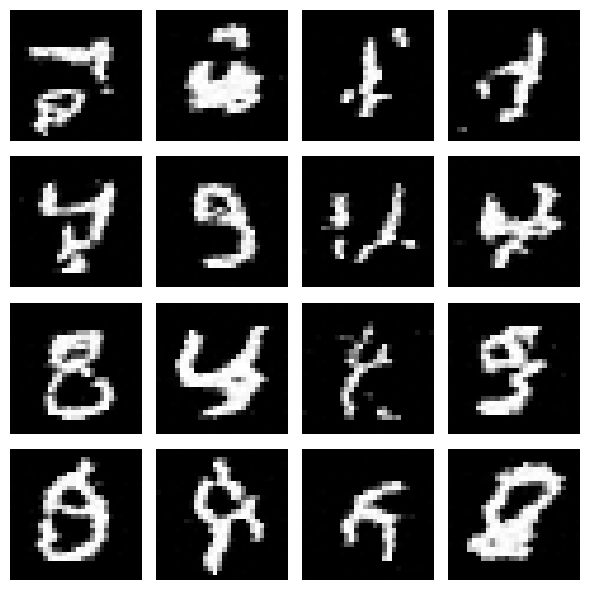

In [30]:
flow.model.eval()
samples = flow.sample(shape=(16, 1, 28, 28), n_steps=100, cond=None, device=device)
samples = (samples.clamp(-1, 1) + 1) / 2      
samples = samples.cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0], cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()


0.2135255268216133


Text(0, 0.5, 'cosine(x, positional_encoding)')

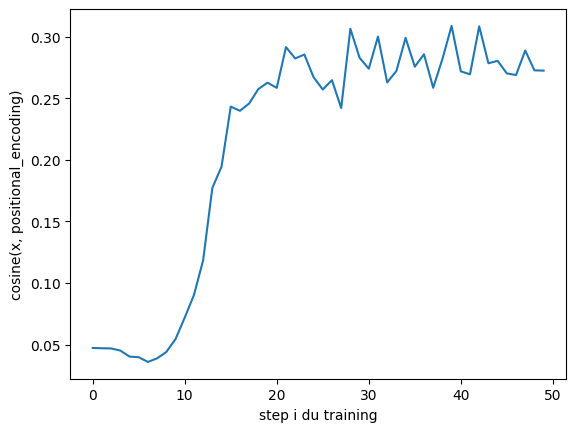

In [ ]:
print(np.mean(np.array(list_cosine)))
plt.plot(list_cosine)
plt.xlabel("step i du training")
plt.ylabel("cosine(x, positional_encoding)")

ça monte et ça change pas en fonction de dim_emb comme prévu parce que, le biais rendait les vecteurs non centré. Par conséquent les 2 vecteurs pointaient un peu vers 1 d'où leur corrélation. Néanmoins avant de passer à l'attention on a une layer norm, donc ce n'est pas vraiment ce que voit l'attention. Ce qui m'intéresse c'est ce que voit l'attention

Pourquoi garder la même cond_dim et emb_dim à travers tous les transformers block??

Revoir comment fonctionne buffer!
Revoir comment on fait en additionant pour compléter? time_cond et cond

## Questions

Why Q and K and not a single matrix M? 
- Low dimensionality - less parameters

Follow up? Link between Q,K and V?